In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from scipy import stats
from scipy.stats import rankdata
import seaborn as sns

In [5]:
# import test_salaries.csv as a pandas dataframe
df = pd.read_csv('salaries_3000.csv')
# separate the first 100 rows of the dataframe into a new dataframe and the last 100 rows into another dataframe
df_m = df.iloc[:1500]
df_f = df.iloc[1500:]

FileNotFoundError: [Errno 2] No such file or directory: 'salaries_3000.csv'

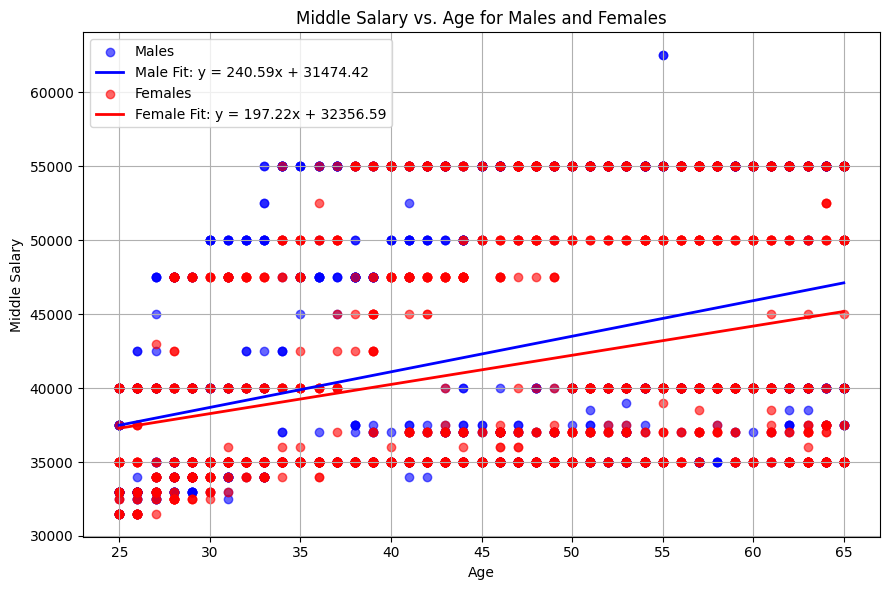

Middle Salary for Males: 42246.33
Middle Salary for Females: 41251.33


In [ ]:
# Extract data
ages_m = df_m['age']
salaries_m = df_m['middle_salary']

ages_f = df_f['age']
salaries_f = df_f['middle_salary']

# --- Male regression ---
n_m = len(ages_m)
x_mean_m = sum(ages_m) / n_m
y_mean_m = sum(salaries_m) / n_m
slope_m = sum((ages_m.iloc[i] - x_mean_m) * (salaries_m.iloc[i] - y_mean_m) for i in range(n_m)) / \
          sum((ages_m.iloc[i] - x_mean_m)**2 for i in range(n_m))
intercept_m = y_mean_m - slope_m * x_mean_m

# --- Female regression ---
n_f = len(ages_f)
x_mean_f = sum(ages_f) / n_f
y_mean_f = sum(salaries_f) / n_f
slope_f = sum((ages_f.iloc[i] - x_mean_f) * (salaries_f.iloc[i] - y_mean_f) for i in range(n_f)) / \
          sum((ages_f.iloc[i] - x_mean_f)**2 for i in range(n_f))
intercept_f = y_mean_f - slope_f * x_mean_f

# Regression line values
x_vals = sorted(set(ages_m) | set(ages_f))  # Union of all unique age values
y_vals_m = [slope_m * x + intercept_m for x in x_vals]
y_vals_f = [slope_f * x + intercept_f for x in x_vals]

# --- Plotting ---
plt.figure(figsize=(9, 6))
plt.scatter(ages_m, salaries_m, color='blue', alpha=0.6, label='Males')
plt.plot(x_vals, y_vals_m, color='blue', linewidth=2, label=f'Male Fit: y = {slope_m:.2f}x + {intercept_m:.2f}')

plt.scatter(ages_f, salaries_f, color='red', alpha=0.6, label='Females')
plt.plot(x_vals, y_vals_f, color='red', linewidth=2, label=f'Female Fit: y = {slope_f:.2f}x + {intercept_f:.2f}')

plt.title('Middle Salary vs. Age for Males and Females')
plt.xlabel('Age')
plt.ylabel('Middle Salary')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# also print the mean salary for M and F
mean_salary_m = salaries_m.mean() 
mean_salary_f = salaries_f.mean()
print(f'Middle Salary for Males: {mean_salary_m:.2f}')
print(f'Middle Salary for Females: {mean_salary_f:.2f}')

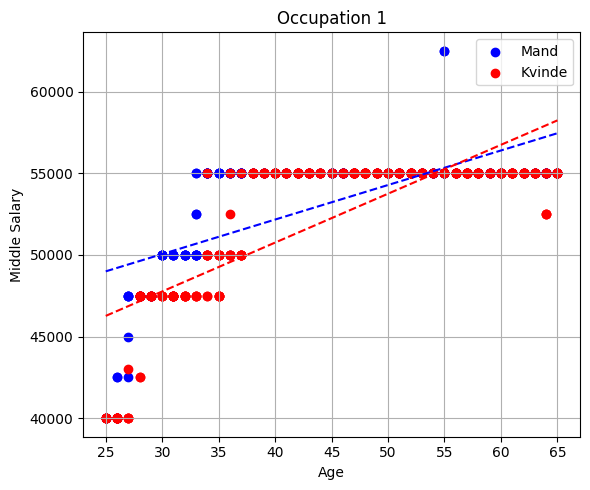

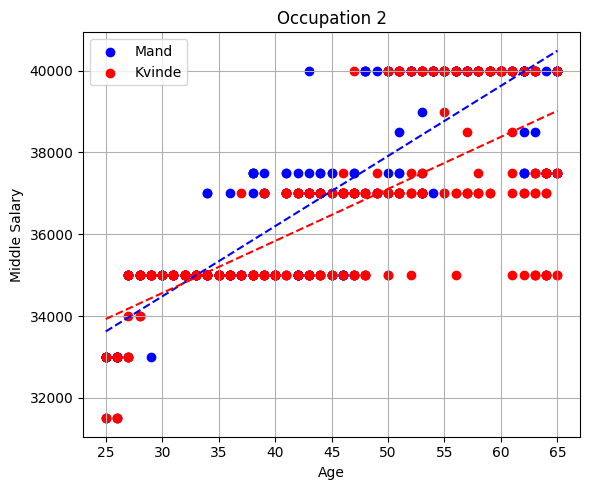

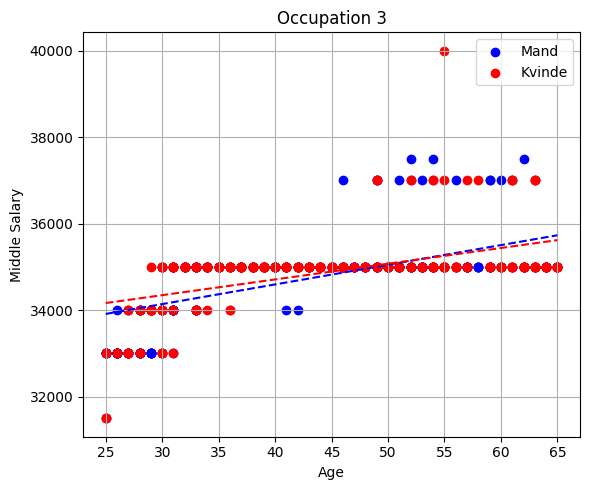

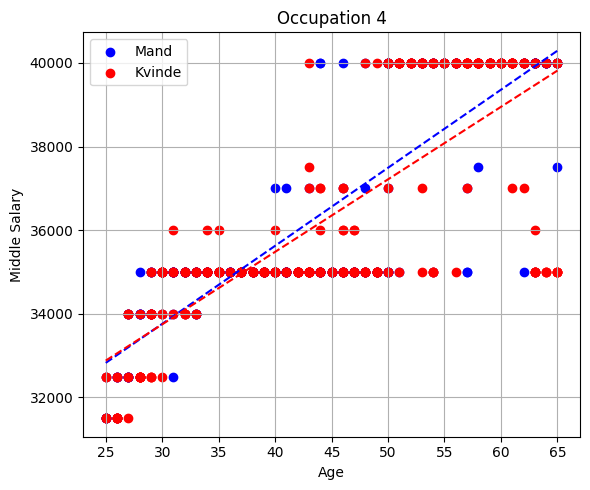

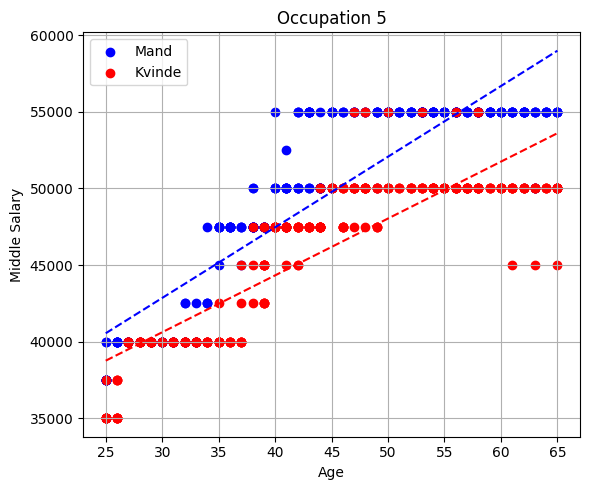

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# Indlæs data
df = pd.read_csv("salaries_3000.csv")  # Erstat med korrekt sti

# Farver og labels
colors = {'M': 'blue', 'F': 'red'}
labels = {'M': 'Mand', 'F': 'Kvinde'}

# Gennemløb hver occupation og lav et separat plot
occupations = sorted(df["occupation"].unique())

for occ in occupations:
    subset = df[df["occupation"] == occ]
    plt.figure(figsize=(6, 5))

    for gender in ['M', 'F']:
        data = subset[subset["gender"] == gender]
        plt.scatter(data["age"], data["middle_salary"], color=colors[gender], label=labels[gender])

        # Lineær regression hvis der er nok data
        if len(data) > 1:
            X = data["age"].values.reshape(-1, 1)
            y = data["middle_salary"].values
            model = LinearRegression().fit(X, y)
            x_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
            y_pred = model.predict(x_range)
            plt.plot(x_range, y_pred, color=colors[gender], linestyle='--')

    plt.title(f"Occupation {occ}")
    plt.xlabel("Age")
    plt.ylabel("Middle Salary")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
# Extract the salary data and group labels
mean_salaries = df["middle_salary"].values
x = mean_salaries[:1500]
y = mean_salaries[1500:]

n1 = len(x)
n2 = len(y)

# Combine data with group labels
all_values = np.concatenate([x, y])
groups = np.array(['M'] * n1 + ['F'] * n2)

# Rank the combined values
ranks = rankdata(all_values)  # average ranks for ties

# Create a DataFrame to see everything clearly
ranked_df = pd.DataFrame({
    'value': all_values,
    'rank': ranks,
    'group': groups
}).sort_values(by='rank').reset_index(drop=True)

print(ranked_df.head(200))  # see the top 10 ranks values

     value   rank group
0    31500   13.0     M
1    31500   13.0     F
2    31500   13.0     F
3    31500   13.0     F
4    31500   13.0     F
..     ...    ...   ...
195  34000  177.0     F
196  34000  177.0     F
197  34000  177.0     F
198  34000  177.0     F
199  34000  177.0     F

[200 rows x 3 columns]


In [ ]:
# Assuming x and y are your arrays for male and female salaries
# Make sure to compare only up to the length of the smaller group
length = min(len(x), len(y))

count_m_greater = 0
count_f_greater = 0
count_m_equal_f = 0
for i in range(length):
    if x[i] > y[i]:
        count_m_greater += 1
    elif x[i] < y[i]:
        count_f_greater += 1
    elif x[i] == y[i]:
        count_m_equal_f += 1

print(f"Number of pairs where male earns more than female: {count_m_greater} out of {length}")
print(f"Number of pairs where female earns more than male: {count_f_greater} out of {length}")
print(f"Number of pairs where male and female earn the same: {count_m_equal_f} out of {length}")


Number of pairs where male earns more than female: 550 out of 1500
Number of pairs where female earns more than male: 366 out of 1500
Number of pairs where male and female earn the same: 584 out of 1500


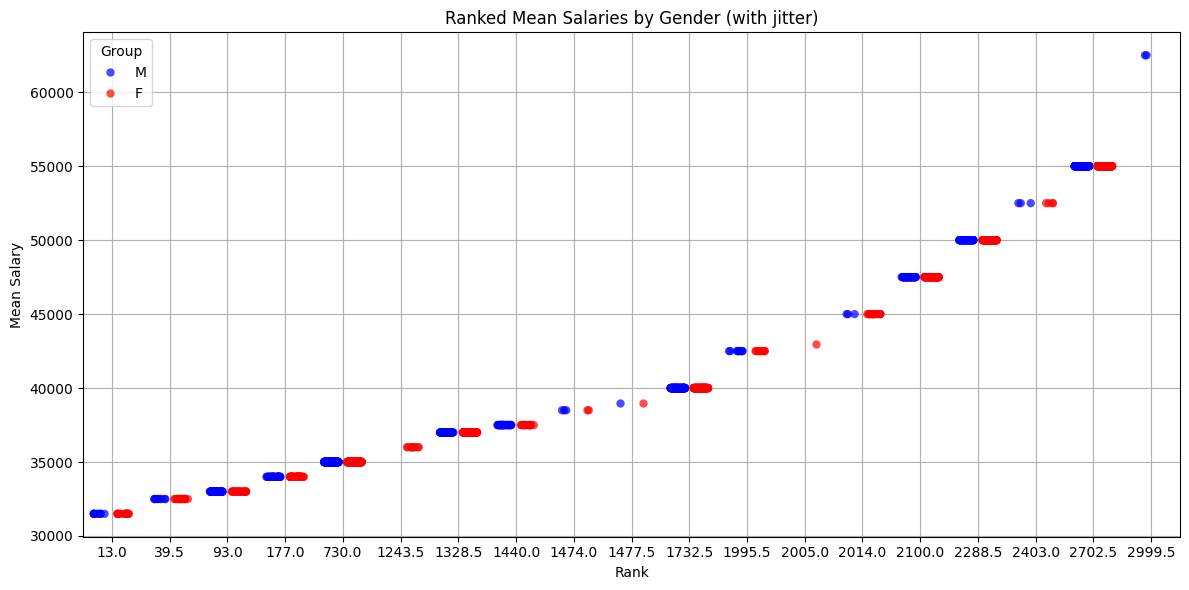

In [ ]:
plt.figure(figsize=(12, 6))
sns.stripplot(
    data=ranked_df,
    x='rank',
    y='value',
    hue='group',
    palette={'M': 'blue', 'F': 'red'},
    jitter=0.25,   # Spread dots horizontally
    dodge=True,    # Separate M and F a bit
    alpha=0.7,
    size=6
)

plt.title('Ranked Mean Salaries by Gender (with jitter)')
plt.xlabel('Rank')
plt.ylabel('Mean Salary')
plt.legend(title='Group')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
from scipy.stats import rankdata
import pandas as pd
import numpy as np


# Build DataFrame of ranks and groups
df_ranks = pd.DataFrame({
    'Rank': ranks,
    'Group': groups
})

# Group by unique rank and count each gender
summary_table = df_ranks.groupby(['Rank', 'Group']).size().unstack(fill_value=0).reset_index()

# Optional: Rename for clarity
summary_table.columns.name = None
summary_table = summary_table.rename(columns={'M': '# Male', 'F': '# Female'})

print(summary_table)

# Compute rank sums
R1 = df_ranks.loc[df_ranks['Group'] == 'M', 'Rank'].sum()
R2 = df_ranks.loc[df_ranks['Group'] == 'F', 'Rank'].sum()

print(f"R1 (Male rank sum): {R1:.1f}")
print(f"R2 (Female rank sum): {R2:.1f}")


      Rank  # Female  # Male
0     13.0        16       9
1     39.5        19       9
2     93.0        26      53
3    177.0        51      38
4    730.0       512     505
5   1243.5        10       0
6   1328.5       101      59
7   1440.0        21      42
8   1474.0         2       3
9   1477.5         1       1
10  1732.5       248     260
11  1995.5         9       9
12  2005.0         1       0
13  2014.0        14       3
14  2100.0        99      56
15  2288.5       155      67
16  2403.0         4       3
17  2702.5       211     381
18  2999.5         0       2
R1 (Male rank sum): 2313780.0
R2 (Female rank sum): 2187720.0


In [ ]:
# Combine and rank all values
all_values = np.concatenate([x, y])
ranks = rankdata(all_values)  # assigns average ranks for ties

# Assign ranks back to original groups
ranks_x = ranks[:n1]
ranks_y = ranks[n1:]

# Sum ranks
R1 = np.sum(ranks_x)
R2 = np.sum(ranks_y)

# Compute U values
U1 = n1 * n2 + n1 * (n1 + 1) / 2 - R1
U2 = n1 * n2 + n2 * (n2 + 1) / 2 - R2

U = min(U1, U2)

# Compute mean and std for normal approximation
mu_U = n1 * n2 / 2
sigma_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)

# Compute Z-score
Z = (U - mu_U) / sigma_U

print(f"U = {U:.2f}")
print(f"Z = {Z:.2f}")
print(f"abs(Z) = {abs(Z):.2f}")
print(f"From table, p is approximately {2*stats.norm.sf(abs(Z)):.4f} (two-tailed)")


U = 1061970.00
Z = -2.66
abs(Z) = 2.66
From table, p is approximately 0.0079 (two-tailed)


In [ ]:
count = 0
for xi in x:
    for yj in y:
        if xi > yj:
            count += 1

A = count / (n1 * n2)
print(f"Count of pairs (X > Y): {count}")
print(f"Estimated A = P(X > Y) = {A:.4f}")

Count of pairs (X > Y): 973043
Estimated A = P(X > Y) = 0.4325


In [ ]:
from scipy.stats import norm
import numpy as np

# Given values:
A = 0.4325
delta = abs(A - 0.5)

alpha = 0.05
z_alpha = norm.ppf(1 - alpha/2)  # 1.96 for two-tailed 0.05

n1 = len(x)
n2 = len(y)
n = min(n1, n2)  # assume balanced sample size for approximation

z_beta = np.sqrt(12) * delta * np.sqrt(n) - z_alpha
power = norm.cdf(z_beta)

print(f"Estimated power of Mann-Whitney U test: {power:.4f}")


Estimated power of Mann-Whitney U test: 1.0000


## CLT and more below (is not used)


In [ ]:
# Extract the mean_salary column as a list
salaries = df_m['middle_salary'].tolist()

# Number of data points
n = len(salaries)

# Calculate the mean
mean_salary = sum(salaries) / n

# Calculate the sum of squared differences from the mean
squared_diffs = [(x - mean_salary) ** 2 for x in salaries]

# Calculate the sample variance (denominator is n - 1 for unbiased estimate)
variance = sum(squared_diffs) / (n - 1)

# Calculate the standard deviation
std_dev = variance ** 0.5

print("Mean salary:", mean_salary)
print("Variance:", variance)
print("Standard Deviation:", std_dev)
n


Mean salary: 42246.333333333336
Variance: 72158925.83944729
Standard Deviation: 8494.641007096609


1500

In [ ]:
# Standardize mean_salary values (compute z-scores)
z_scores = [(x - mean_salary) / std_dev for x in salaries]

# # Optional: add the z-scores as a new column in df_m
# df_m = df_m.copy()  # To avoid modifying the original dataframe directly
# df_m['z_score'] = z_scores


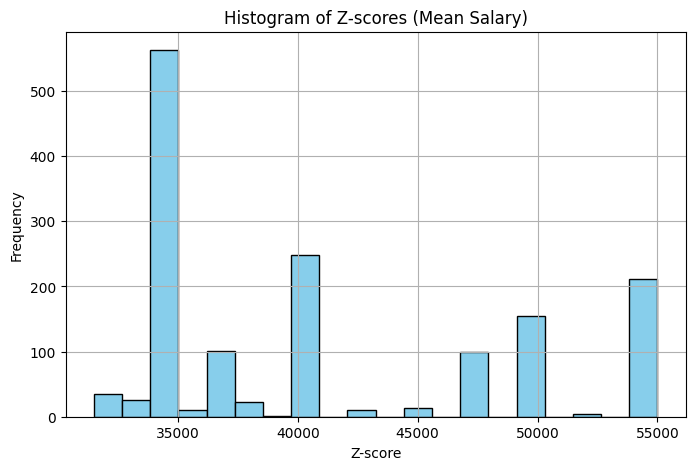

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df_f['middle_salary'], bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Z-scores (Mean Salary)')
plt.xlabel('Z-score')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


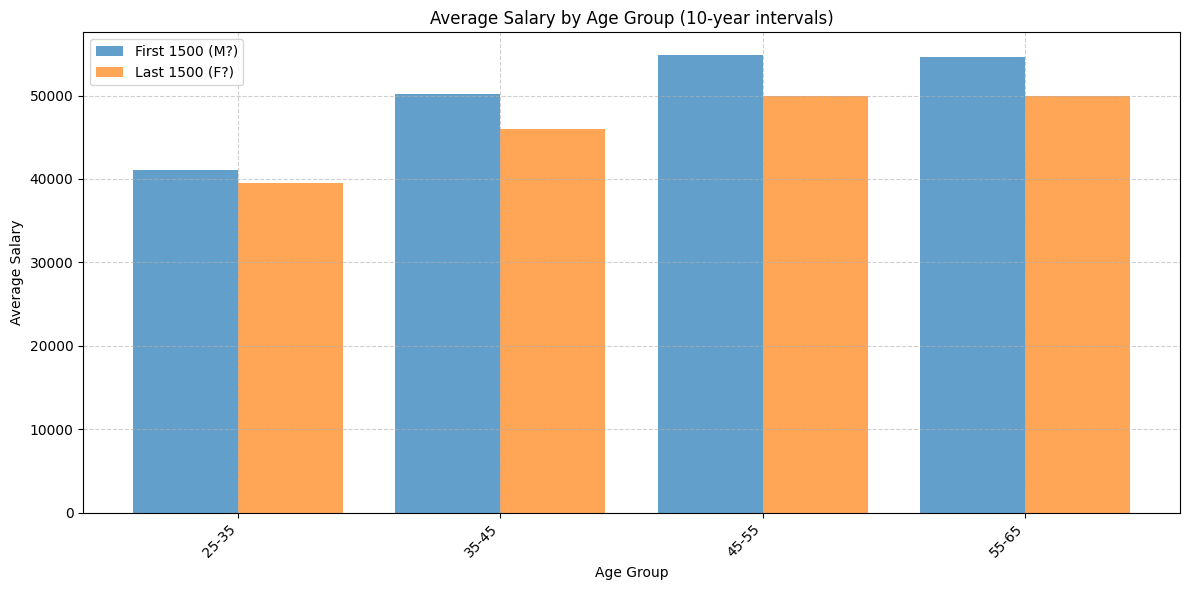

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_csv('salaries_3000.csv')

# Split into two groups (avoid SettingWithCopyWarning by using .copy())
df_m = df.iloc[1200:1500].copy()  # Explicit copy
df_f = df.iloc[2700:3000].copy()  # Explicit copy

# Bin ages into 10-year intervals
bin_width = 10
min_age = min(df['age'].min(), df['age'].min())
max_age = max(df['age'].max(), df['age'].max())
bins = np.arange(min_age, max_age + bin_width, bin_width)

# Create labels (e.g., "20-30", "30-40", etc.)
bin_labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]

# Assign age bins (no more SettingWithCopyWarning due to .copy())
df_m.loc[:, 'age_bin'] = pd.cut(df_m['age'], bins=bins, labels=bin_labels)
df_f.loc[:, 'age_bin'] = pd.cut(df_f['age'], bins=bins, labels=bin_labels)

# Compute mean salary per bin (suppress FutureWarning with observed=True)
mean_salary_m = df_m.groupby('age_bin', observed=True)['middle_salary'].mean()
mean_salary_f = df_f.groupby('age_bin', observed=True)['middle_salary'].mean()

# Plotting
plt.figure(figsize=(12, 6))
bar_width = 0.4
x = np.arange(len(bin_labels))

plt.bar(x - bar_width/2, mean_salary_m, width=bar_width, label='First 1500 (M?)', alpha=0.7)
plt.bar(x + bar_width/2, mean_salary_f, width=bar_width, label='Last 1500 (F?)', alpha=0.7)

plt.xlabel('Age Group')
plt.ylabel('Average Salary')
plt.title('Average Salary by Age Group (10-year intervals)')
plt.xticks(x, bin_labels, rotation=45, ha='right')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

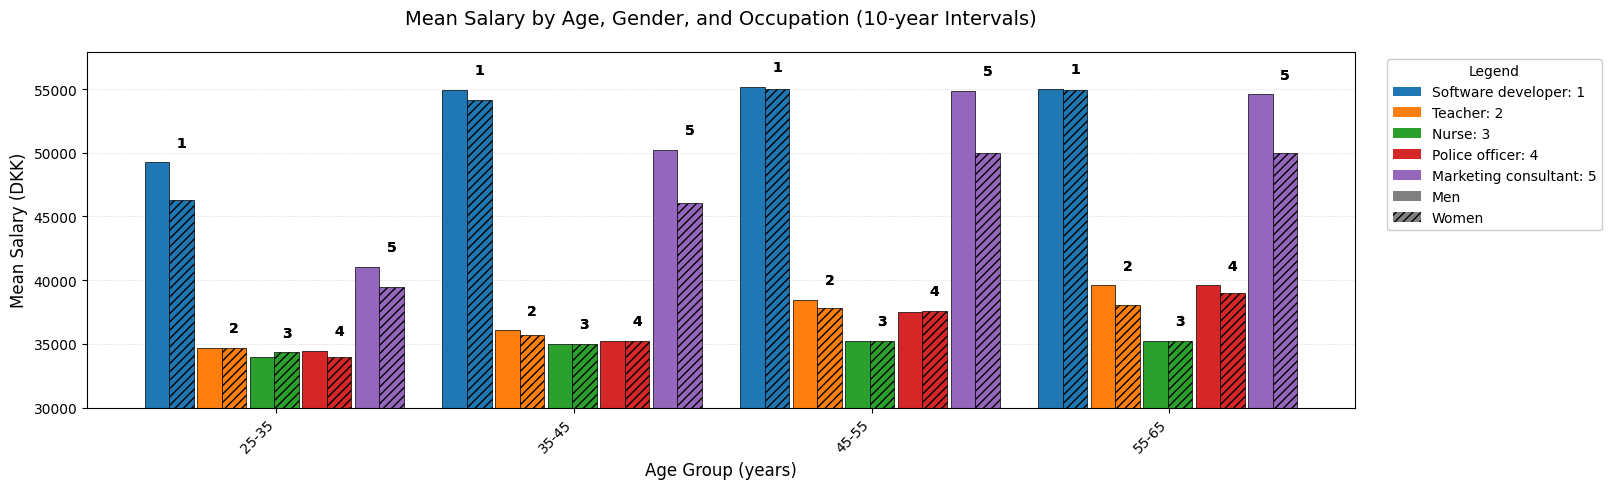

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Load data
df = pd.read_csv('salaries_3000.csv')

# Bin ages into 10-year intervals
bin_width = 10
min_age = df['age'].min()
max_age = df['age'].max()
bins = np.arange(min_age, max_age + bin_width, bin_width)
bin_labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]

# Assign age bins
df['age_bin'] = pd.cut(df['age'], bins=bins, labels=bin_labels)

# Group by age bin, gender, and occupation (compute mean salary)
grouped = df.groupby(['age_bin', 'gender', 'occupation'], observed=True)['middle_salary'].mean().unstack(['gender', 'occupation'])

# Define colors for occupations (5 distinct colors)
occupation_colors = plt.cm.tab10.colors[:5]

# Plotting
fig, ax = plt.subplots(figsize=(16, 5))
bar_width = 0.35  # Width for each gender bar
gap_width = 0.05   # Small gap between occupation groups
group_width = (bar_width * 2) + gap_width  # Width for each occupation group (M+F bars)

# Add extra spacing between age groups
age_group_spacing = 0.5  # Increase this value for more space
x = np.arange(len(bin_labels)) * (len(range(1, 6)) * group_width + age_group_spacing)

# Plot bars for each occupation and gender
for j, occupation in enumerate(range(1, 6)):
    for i, gender in enumerate(['M', 'F']):
        offset = j * group_width + i * bar_width
        hatch = '////' if gender == 'F' else ''
        bars = ax.bar(
            x + offset,
            grouped[(gender, occupation)],
            width=bar_width,
            color=occupation_colors[j],
            edgecolor='black',
            hatch=hatch,
            linewidth=0.5
        )
        
        # Add occupation number inside bars
        # Add one occupation number per pair of bars (centered above both bars)
        for idx in range(len(bin_labels)):
            # X position: center between the two bars
            male_bar_pos = x[idx] + j * group_width
            female_bar_pos = x[idx] + j * group_width + bar_width
            center_pos = (male_bar_pos + female_bar_pos + bar_width) / 2

            # Y position: top of the tallest bar (men or women)
            male_height = grouped[('M', occupation)].iloc[idx]
            female_height = grouped[('F', occupation)].iloc[idx]
            max_height = max(male_height, female_height)

            ax.text(
                center_pos,
                max_height + 1000,  # Adjust this offset if needed
                str(occupation),
                ha='center',
                va='bottom',
                color='black',
                fontweight='bold',
                fontsize=10
            )


# Customize plot
ax.set_xlabel('Age Group (years)', fontsize=12)
ax.set_ylabel('Mean Salary (DKK)', fontsize=12)
ax.set_title('Mean Salary by Age, Gender, and Occupation (10-year Intervals)', fontsize=14, pad=20)

# Set x-ticks at the center of each age group
tick_positions = x + ((group_width * len(['M', 'F'])) * 5 / 2) / 2 - (bar_width / 2)
ax.set_xticks(tick_positions)
ax.set_xticklabels(bin_labels, rotation=45, ha='right')

# Add grid lines
ax.yaxis.grid(True, linestyle=':', linewidth=0.5, alpha=0.7)
ax.set_axisbelow(True)

ax.set_ylim(30000, )

# Create legend
occupations = ['Software developer', 'Teacher', 'Nurse', 'Police officer', 'Marketing consultant']
legend_elements = [
    *[Patch(facecolor=occupation_colors[i], label=f'{occupations[i]}: {i+1}') for i in range(5)],
    Patch(facecolor='gray', hatch='', label='Men'),
    Patch(facecolor='gray', hatch='////', label='Women')
]
ax.legend(handles=legend_elements, bbox_to_anchor=(1.02, 1), loc='upper left', 
          title='Legend', framealpha=1)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(right=0.85)  # Make space for legend
plt.show()

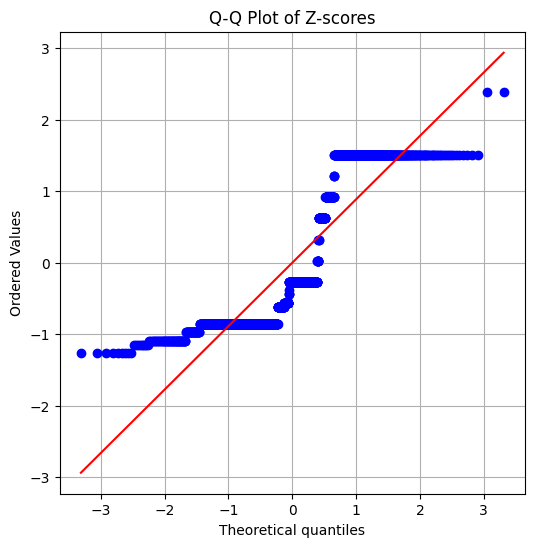

In [ ]:
plt.figure(figsize=(6, 6))
stats.probplot(z_scores, dist="norm", plot=plt)
plt.title("Q-Q Plot of Z-scores")
plt.grid(True)
plt.show()

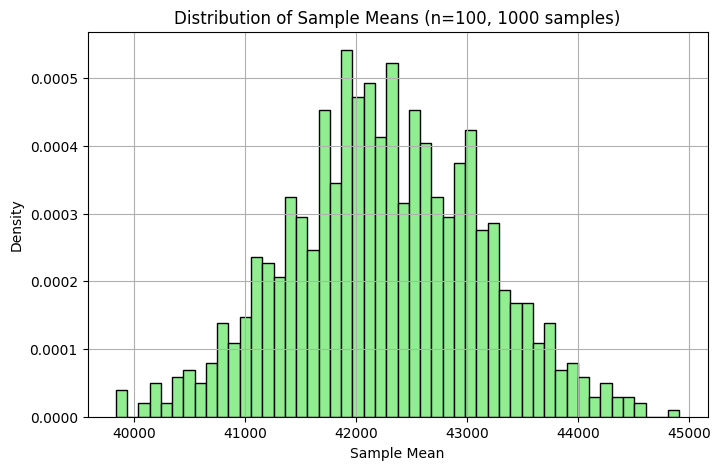

In [ ]:
# Seed the random number generator for reproducibility
random.seed(0)

# Step 1: Parameters
sample_size = 100         # e.g., size of each sample (CLT kicks in nicely from n ≥ 30)
num_samples = 1000       # number of samples to draw

# Step 2: Generate the sample means
sample_means = []

for _ in range(num_samples):
    sample = random.choices(salaries, k=sample_size)  # sampling with replacement
    sample_mean = sum(sample) / sample_size
    sample_means.append(sample_mean)

# Step 3: Plot the distribution of sample means
plt.figure(figsize=(8, 5))
plt.hist(sample_means, bins=50, color='lightgreen', edgecolor='black', density=True)
plt.title(f'Distribution of Sample Means (n={sample_size}, {num_samples} samples)')
plt.xlabel('Sample Mean')
plt.ylabel('Density')
plt.grid(True)
plt.show()


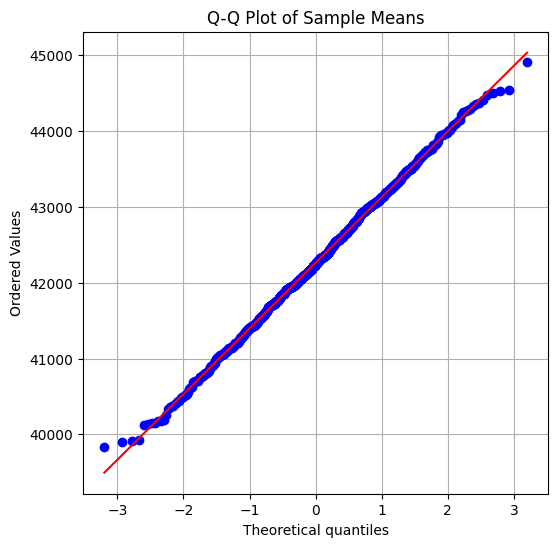

In [ ]:
plt.figure(figsize=(6, 6))
stats.probplot(sample_means, dist="norm", plot=plt)
plt.title("Q-Q Plot of Sample Means")
plt.grid(True)
plt.show()

In [ ]:
# Import libraries
from scipy import stats
from scipy.stats import mannwhitneyu

# Defining data groups
soft_m = list(df['middle_salary'][:300])
teac_m = list(df['middle_salary'][300:600])
nurse_m = list(df['middle_salary'][600:900])
poli_m = list(df['middle_salary'][900:1200])
mark_m = list(df['middle_salary'][1200:1500])
male = list(df_m['middle_salary'])
female = list(df_f['middle_salary'])

# perform mann whitney test
stat, p_value = mannwhitneyu(male, female)
print('Statistics=%.2f, p=%.15f' % (stat, p_value))
# Level of significance
alpha = 0.05
# conclusion
if p_value < alpha:
    print('Reject Null Hypothesis (Significant difference between two samples)')
else:
    print('Do not Reject Null Hypothesis (No significant difference between two samples)')

Statistics=1188030.00, p=0.006345487530275
Reject Null Hypothesis (Significant difference between two samples)


In [ ]:
data_group1 = list(df['middle_salary'][:100])
data_group2 = list(df['middle_salary'][100:200])
data_group3 = list(df['middle_salary'][200:300])
# Conduct the Kruskal-Wallis Test 
result = stats.kruskal(data_group1, data_group2, data_group3)

# Print the result
print(result)

np.array(data_group1).mean(),np.array(data_group2).mean(), np.array(data_group3).mean()

KruskalResult(statistic=10.465556945689354, pvalue=0.005338671323228367)


(53575.0, 54025.0, 52550.0)